# Notebook 07 — Clustering delle Aree Interne
**Capstone: Aree Interne Italiane** | Gianluca Tommasino — Aprile 2026

La classificazione SNAI (A→F) si basa su un solo criterio: la distanza in minuti
dal polo di riferimento piu vicino. E una misura di accessibilita fisica,
non di condizione socioeconomica.

Due comuni classificati entrambi come "E - Periferico" possono avere
storie molto diverse: uno con redditi relativamente alti e popolazione stabile,
l'altro in caduta su tutti i fronti da decenni.

L'obiettivo di questo notebook e costruire una classificazione alternativa
basata su piu dimensioni insieme:
- isolamento geografico (distanza dal polo)
- dimensione demografica e traiettoria
- livello e dinamica del reddito
- finanziamenti SNAI ricevuti nel 14-20

Il metodo usato e **K-Means**, con StandardScaler per normalizzare le variabili
e il metodo elbow + silhouette score per scegliere il numero ottimale di cluster.

In [1]:
import os
os.chdir(r'C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE')
print("Working directory:", os.getcwd())

Working directory: C:\Users\tomma\OneDrive\Desktop\EPICODE\CAPSTONE


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

PROCESSED_DIR = "data/processed/"
OUTPUT_DIR    = "outputs/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

C_DARK   = "#1F4E79"
C_MED    = "#2E75B6"
C_LIGHT  = "#9DC3E6"
C_ORANGE = "#F4A460"
C_BROWN  = "#CD853F"

print("Setup OK")

Setup OK


## 1. Preparazione dei dati

Partiamo dal dataset `impact_analysis_powerbi.csv` costruito nel notebook precedente.
Selezioniamo solo le Aree Interne (D/E/F) e le 6 variabili di input per il clustering.

Tutte le variabili vengono normalizzate con **StandardScaler**
(media 0, deviazione standard 1) in modo che nessuna scala numerica
domini le altre. Senza questo passaggio, il reddito in euro
avrebbe un peso sproporzionato rispetto a variabili percentuali.

In [3]:
df = pd.read_csv(PROCESSED_DIR + "impact_analysis_powerbi.csv", dtype=str)

num_cols = [
    "tempi_percorrenza_min", "pop_2018", "pop_2026", "var_pct_18_26",
    "reddito_2022", "var_reddito_18_22", "finanz_totale_1420"
]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

ai = df[df["is_area_interna"] == "1"].copy()

# Rimuoviamo righe con valori mancanti nelle variabili di clustering
FEAT = ["tempi_percorrenza_min", "pop_2018", "pop_2026", "var_pct_18_26",
        "reddito_2022", "var_reddito_18_22", "finanz_totale_1420"]

ai_clean = ai.dropna(subset=FEAT).copy()
print(f"Comuni totali Aree Interne: {len(ai)}")
print(f"Usabili per clustering (no NaN): {len(ai_clean)}")
print()
print("Statistiche descrittive delle variabili:")
print(ai_clean[FEAT].describe().round(2))

Comuni totali Aree Interne: 3564
Usabili per clustering (no NaN): 3549

Statistiche descrittive delle variabili:
       tempi_percorrenza_min  pop_2018  var_pct_18_23  reddito_2022  \
count                3549.00   3549.00        3549.00       3549.00   
mean                   44.66   3656.68          -3.84      18558.91   
std                    15.36   6172.46           5.08       3919.97   
min                    27.80     32.00         -43.75       7403.00   
25%                    33.30    731.00          -6.86      15580.00   
50%                    40.60   1612.00          -3.77      18469.00   
75%                    51.80   3823.00          -0.81      21067.00   
max                   317.60  72890.00          54.91      97059.00   

       var_reddito_18_22  finanz_totale_1420  
count            3549.00             3549.00  
mean               11.63           140602.97  
std                 6.55           601748.51  
min               -51.86                0.00  
25%         

In [4]:
# Normalizzazione
scaler = StandardScaler()
X = scaler.fit_transform(ai_clean[FEAT])

print("Variabili normalizzate — media e std dopo scaling:")
df_scaled = pd.DataFrame(X, columns=FEAT)
print(df_scaled.describe().loc[["mean","std"]].round(3))

Variabili normalizzate — media e std dopo scaling:
      tempi_percorrenza_min  pop_2018  var_pct_18_23  reddito_2022  \
mean                    0.0       0.0           -0.0          -0.0   
std                     1.0       1.0            1.0           1.0   

      var_reddito_18_22  finanz_totale_1420  
mean                0.0                 0.0  
std                 1.0                 1.0  


## 2. Scelta del numero di cluster

Due criteri per scegliere K:

- **Elbow method**: calcola l'inertia (somma delle distanze quadratiche intra-cluster)
  al variare di K. Si sceglie il punto in cui la curva "piega" — aggiungere un cluster
  in piu non porta un miglioramento proporzionale.

- **Silhouette score**: misura quanto ogni punto e simile al suo cluster
  rispetto agli altri. Varia tra -1 e 1, valori alti indicano cluster ben separati.

I due criteri non sempre concordano; in quel caso si preferisce
la soluzione piu interpretabile dal punto di vista sostanziale.

  K=2  inertia=17,939  silhouette=0.2024
  K=3  inertia=15,759  silhouette=0.2081
  K=4  inertia=14,215  silhouette=0.1883
  K=5  inertia=12,210  silhouette=0.2146
  K=6  inertia=10,796  silhouette=0.2160
  K=7  inertia=10,081  silhouette=0.1974
  K=8  inertia=9,432  silhouette=0.1970
  K=9  inertia=8,852  silhouette=0.1839
  K=10  inertia=8,227  silhouette=0.1768


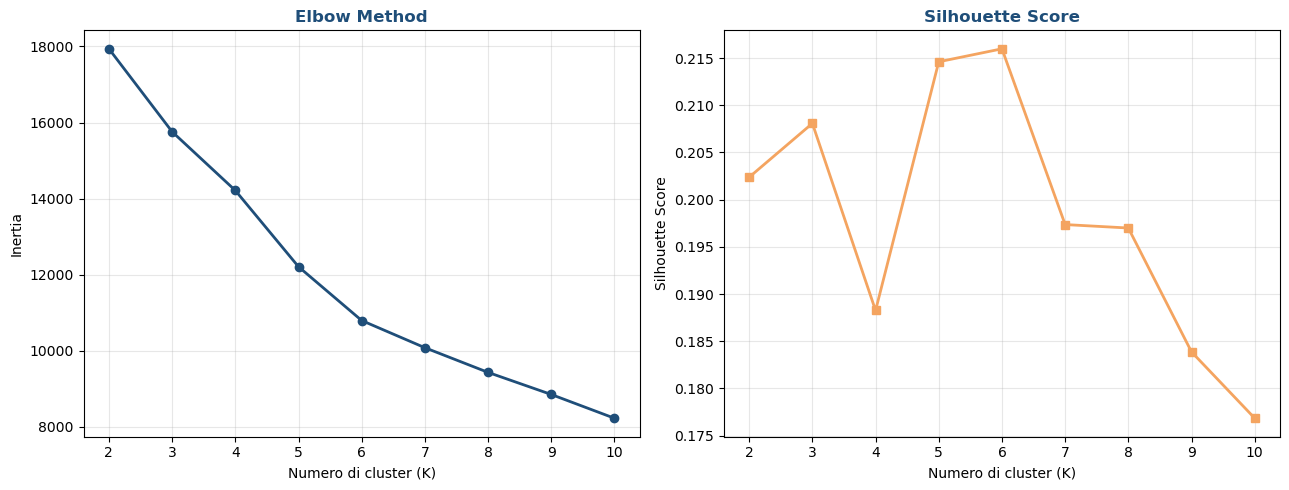

In [5]:
inertie = []
silhouette = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertie.append(km.inertia_)
    sil = silhouette_score(X, labels)
    silhouette.append(sil)
    print(f"  K={k}  inertia={km.inertia_:,.0f}  silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(list(K_range), inertie, marker="o", color=C_DARK, linewidth=2)
axes[0].set_xlabel("Numero di cluster (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method", fontsize=12, fontweight="bold", color=C_DARK)
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), silhouette, marker="s", color=C_ORANGE, linewidth=2)
axes[1].set_xlabel("Numero di cluster (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score", fontsize=12, fontweight="bold", color=C_DARK)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb07_elbow_silhouette.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. K-Means con K ottimale

Sulla base dei grafici precedenti scegliamo K.
In genere con dati territoriali di questo tipo 4 o 5 cluster
offrono il miglior compromesso tra separazione statistica e interpretabilita.

In [6]:
# K=6 ha silhouette quasi identica (0.2160) ma aggiunge un cluster senza guadagno interpretativo
K_OTTIMALE = 5

km_final = KMeans(n_clusters=K_OTTIMALE, random_state=42, n_init=20)
ai_clean["cluster"] = km_final.fit_predict(X)

print(f"K-Means con K={K_OTTIMALE} — distribuzione dei cluster:")
print(ai_clean["cluster"].value_counts().sort_index())
print()
sil_fin = silhouette_score(X, ai_clean["cluster"])
print(f"Silhouette score finale: {sil_fin:.4f}")

K-Means con K=5 — distribuzione dei cluster:
cluster
0    1406
1    1365
2     172
3      27
4     579
Name: count, dtype: int64

Silhouette score finale: 0.2146


## 4. Profilo di ciascun cluster

Per capire cosa rappresenta ogni cluster calcoliamo
i valori medi delle variabili originali (non normalizzate)
per ciascun gruppo.
Questo e il passaggio interpretativo piu importante:
assegnare un nome e un significato a ciascun cluster.

In [7]:
profili = ai_clean.groupby("cluster")[FEAT + ["tipo_area","regione"]].agg(
    tempi_perc_medio  = ("tempi_percorrenza_min", "mean"),
    pop_mediana       = ("pop_2018",               "median"),
    var_pop_mediana   = ("var_pct_18_26",           "median"),
    reddito_medio     = ("reddito_2022",            "median"),
    var_redd_mediana  = ("var_reddito_18_22",       "median"),
    finanz_medio      = ("finanz_totale_1420",      "mean"),
    n_comuni          = ("tipo_area",               "count"),
).reset_index()

print("Profili medi per cluster:")
print(profili.to_string(index=False))

# Composizione SNAI per cluster
print()
print("Tipo_area per cluster:")
cross = pd.crosstab(ai_clean["cluster"], ai_clean["tipo_area"],
                    normalize="index").round(2) * 100
print(cross)

Profili medi per cluster:
 cluster  tempi_perc_medio  pop_mediana  var_pop_mediana  reddito_medio  var_redd_mediana  finanz_medio  n_comuni
       0         38.584780       1778.5           -1.030        21216.0            10.270  6.262610e+04      1406
       1         40.556264       1411.0           -6.530        15908.0            12.550  1.187124e+05      1365
       2         37.874419      21353.0           -1.175        19100.0            10.525  8.952843e+04       172
       3         49.570370       3749.0           -4.980        18018.0            12.800  5.563564e+06        27
       4         70.880311       1139.0           -5.460        17014.0            11.520  1.438516e+05       579

Tipo_area per cluster:
tipo_area  Intermedio  Periferico  Ultraperiferico
cluster                                           
0                67.0        33.0              0.0
1                55.0        45.0              0.0
2                68.0        32.0              0.0
3          

In [8]:
#
# C0 — Periferie Settentrionali Funzionanti (n=1406)
#   73% Nord (Lombardia, Piemonte, Trentino), reddito massimo €21.2K,
#   spopolamento quasi assente -1%, Intermedi al 67%.
#   Distanti dai poli ma economicamente vitali: la marginalita geografica
#   non si traduce in crisi socioeconomica.
#
# C1 — Mezzogiorno a Rischio Spopolamento (n=1365)
#   66% Sud e Isole (Calabria, Campania, Sicilia), reddito minimo €15.9K,
#   spopolamento piu acuto -6.5%, distanza simile al C0 (40 min).
#   Il problema non e l'isolamento fisico ma la struttura economica debole.
#
# C2 — Centri Urbani Periferici (n=172)
#   Popolazione mediana 21.000 ab (10x gli altri cluster), stabili demograficamente.
#   Classificate come Aree Interne per distanza, ma sono cittadine vere.
#   59% Sud: spesso capoluogi di zona o poli locali di aree piu piccole.
#
# C3 — Aree Pilota a Investimento Strutturato (n=27)
#   Finanziamento medio €5.5M (80x la media degli altri cluster).
#   Sono i veri accordi di programma SNAI con strategia strutturata.
#   Solo 27 comuni su 3.549: meno dell'1% delle Aree Interne.
#
# C4 — Borghi Remoti ad Alta Fragilita (n=579)
#   Distanza 71 min (quasi doppio degli altri), 56% Ultraperiferici,
#   i piu piccoli (1.139 ab mediana), reddito basso €17K, -5.5% pop.
#   Distribuiti tra Sud (53%) e Nord (39%): l'isolamento fisico e trasversale.

NOMI_CLUSTER = {
    0: "Periferie Settentrionali Funzionanti",
    1: "Mezzogiorno a Rischio Spopolamento",
    2: "Centri Urbani Periferici",
    3: "Aree Pilota a Investimento Strutturato",
    4: "Borghi Remoti ad Alta Fragilita",
}

ai_clean["nome_cluster"] = ai_clean["cluster"].map(NOMI_CLUSTER)
print("Distribuzione cluster:")
for c, nome in NOMI_CLUSTER.items():
    sub = ai_clean[ai_clean["cluster"]==c]
    print(f"  C{c} — {nome:<30} n={len(sub):4d} | "
          f"pop mediana: {sub['pop_2018'].median():>6,.0f} ab | "
          f"reddito: €{sub['reddito_2022'].median():>6,.0f} | "
          f"pop var: {sub['var_pct_18_26'].median():+.1f}%")

Distribuzione cluster:
  C0 — Periferie Settentrionali Funzionanti n=1406 | pop mediana:  1,778 ab | reddito: €21,216 | pop var: -1.0%
  C1 — Mezzogiorno a Rischio Spopolamento n=1365 | pop mediana:  1,411 ab | reddito: €15,908 | pop var: -6.5%
  C2 — Centri Urbani Periferici       n= 172 | pop mediana: 21,353 ab | reddito: €19,100 | pop var: -1.2%
  C3 — Aree Pilota a Investimento Strutturato n=  27 | pop mediana:  3,749 ab | reddito: €18,018 | pop var: -5.0%
  C4 — Borghi Remoti ad Alta Fragilita n= 579 | pop mediana:  1,139 ab | reddito: €17,014 | pop var: -5.5%


## 5. Heatmap dei profili normalizzati

Visualizziamo i centroidi dei cluster nello spazio normalizzato.
Un valore positivo indica che quella variabile e sopra la media,
negativo vuol dire sotto la media.
E il modo piu immediato per vedere le differenze tra cluster.

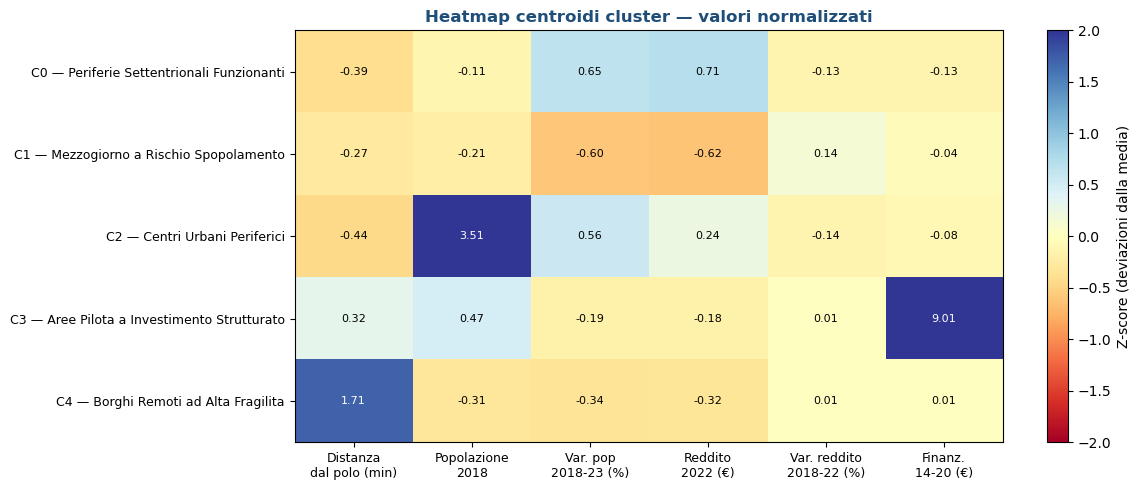

In [9]:
centroids_df = pd.DataFrame(
    scaler.inverse_transform(km_final.cluster_centers_),
    columns=FEAT
)
centroids_norm = pd.DataFrame(
    km_final.cluster_centers_,
    columns=FEAT
)

feat_labels = [
    "Distanza\ndal polo (min)",
    "Popolazione\n2018",
    "Var. pop\n2018-23 (%)",
    "Reddito\n2022 (€)",
    "Var. reddito\n2018-22 (%)",
    "Finanz.\n14-20 (€)"
]

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(centroids_norm.values, cmap="RdYlBu", aspect="auto",
               vmin=-2, vmax=2)

ax.set_xticks(range(len(FEAT)))
ax.set_xticklabels(feat_labels, fontsize=9)
ax.set_yticks(range(K_OTTIMALE))
cluster_ylab = [f"C{i} — {NOMI_CLUSTER.get(i, str(i))}" for i in range(K_OTTIMALE)]
ax.set_yticklabels(cluster_ylab, fontsize=9)

# Annotazioni numeriche
for i in range(K_OTTIMALE):
    for j in range(len(FEAT)):
        val = centroids_norm.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=8, color="black" if abs(val) < 1.2 else "white")

plt.colorbar(im, ax=ax, label="Z-score (deviazioni dalla media)")
ax.set_title("Heatmap centroidi cluster — valori normalizzati",
             fontsize=12, fontweight="bold", color=C_DARK)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb07_heatmap_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Visualizzazione in 2D con PCA

Il clustering avviene in 6 dimensioni, impossibili da visualizzare direttamente.
La **PCA (Principal Component Analysis)** riduce le 6 variabili a 2 componenti
principali che catturano la maggior parte della varianza.

Il grafico scatter che ne risulta mostra la separazione spaziale tra i cluster.
Cluster ben separati nello scatter indicano che l'algoritmo ha trovato
strutture reali nei dati, non solo rumore.

Varianza spiegata da PC1: 25.6%
Varianza spiegata da PC2: 18.5%
Totale PC1+PC2:          44.2%


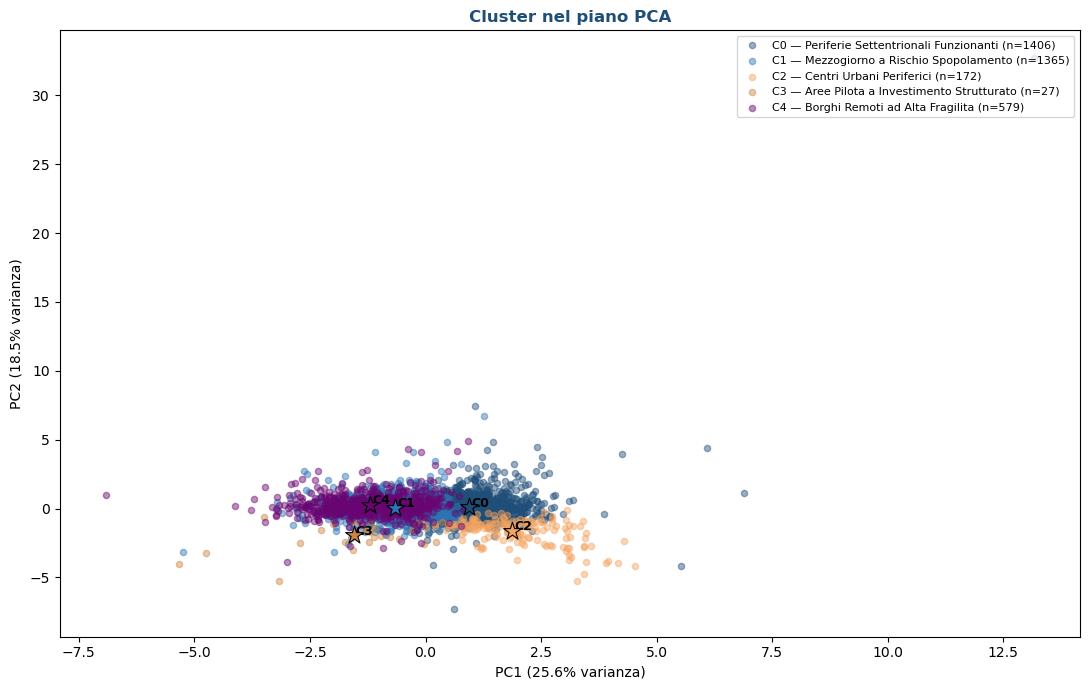

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

var_exp = pca.explained_variance_ratio_
print(f"Varianza spiegata da PC1: {var_exp[0]:.1%}")
print(f"Varianza spiegata da PC2: {var_exp[1]:.1%}")
print(f"Totale PC1+PC2:          {sum(var_exp):.1%}")

PALETTE = [C_DARK, C_MED, C_ORANGE, C_BROWN, "#6A0572"]

fig, ax = plt.subplots(figsize=(11, 7))

for c_id in range(K_OTTIMALE):
    mask = ai_clean["cluster"] == c_id
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=PALETTE[c_id], alpha=0.45, s=20,
        label=f"C{c_id} — {NOMI_CLUSTER.get(c_id, str(c_id))} (n={mask.sum()})"
    )

# Centroidi nel piano PCA
centroids_pca = pca.transform(km_final.cluster_centers_)
for c_id in range(K_OTTIMALE):
    ax.scatter(centroids_pca[c_id, 0], centroids_pca[c_id, 1],
               c=PALETTE[c_id], s=180, marker="*",
               edgecolors="black", linewidths=0.8, zorder=5)
    ax.text(centroids_pca[c_id, 0] + 0.05, centroids_pca[c_id, 1] + 0.05,
            f"C{c_id}", fontsize=9, fontweight="bold")

ax.set_xlabel(f"PC1 ({var_exp[0]:.1%} varianza)", fontsize=10)
ax.set_ylabel(f"PC2 ({var_exp[1]:.1%} varianza)", fontsize=10)
ax.set_title("Cluster nel piano PCA",
             fontsize=12, fontweight="bold", color=C_DARK)
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb07_pca_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Confronto tra cluster: barre multiple

Per ogni variabile originale (non normalizzata) confrontiamo
i valori medi tra cluster.
Questo e il grafico che si usa per descrivere il profilo
di ciascun gruppo in modo leggibile anche da chi non conosce il metodo.

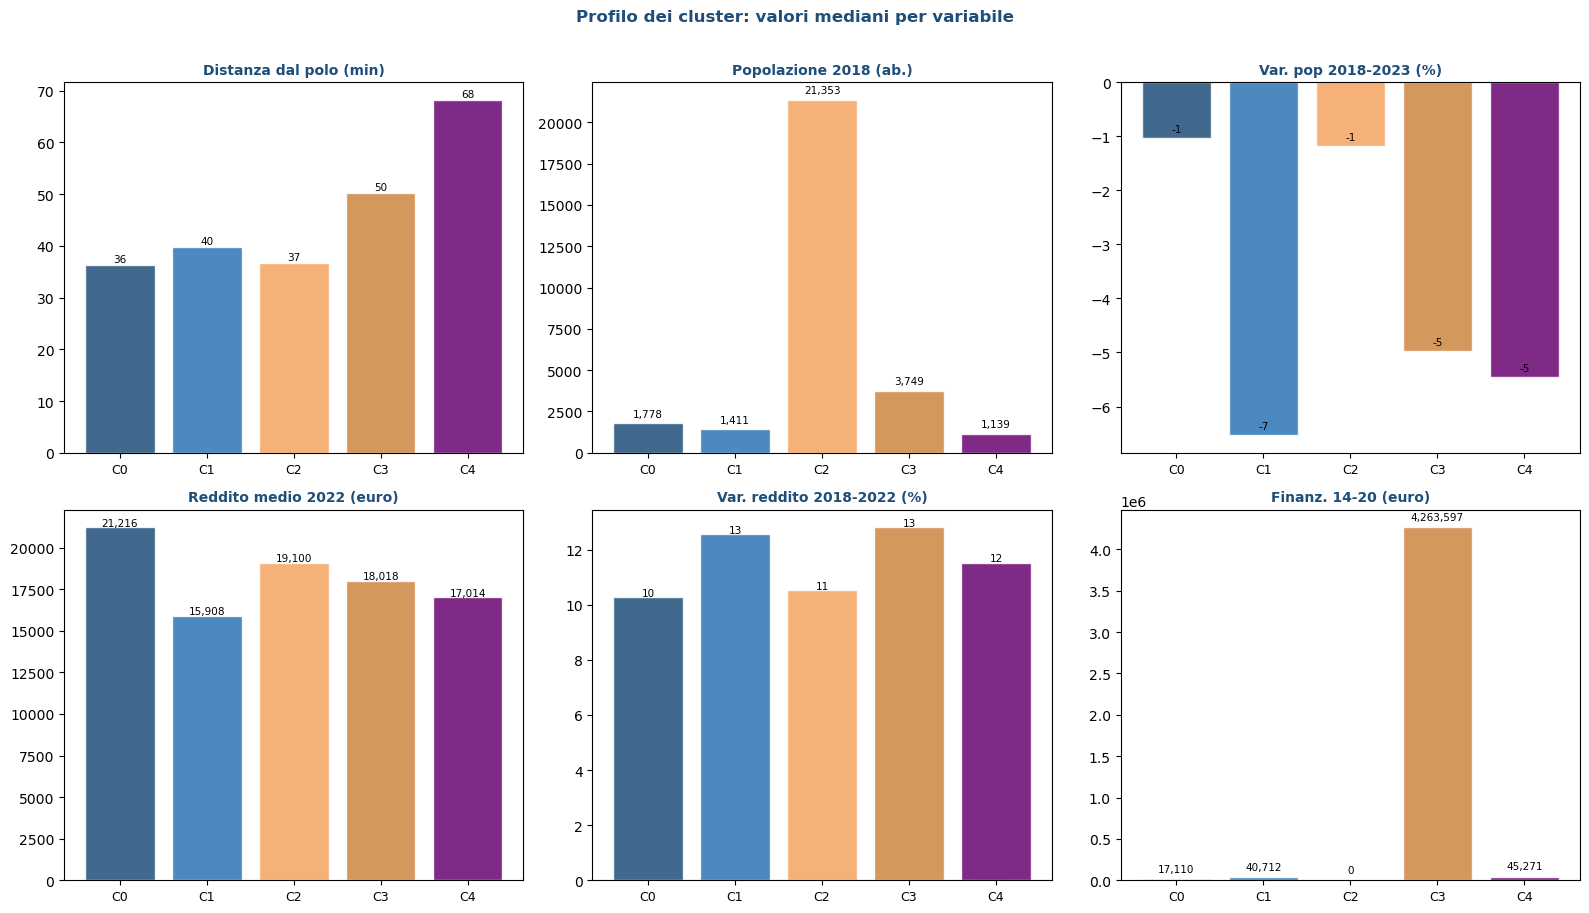

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

feat_plot = [
    ("tempi_percorrenza_min", "Distanza dal polo (min)",    False),
    ("pop_2018",              "Popolazione 2018 (ab.)",     False),
    ("var_pct_18_26",         "Var. pop 2018-2026 (%)",     True),
    ("reddito_2022",          "Reddito medio 2022 (euro)",  False),
    ("var_reddito_18_22",     "Var. reddito 2018-2022 (%)", True),
    ("finanz_totale_1420",    "Finanz. 14-20 (euro)",       False),
]

for ax, (feat, titolo, has_zero) in zip(axes, feat_plot):
    vals_c = []
    for c_id in range(K_OTTIMALE):
        sub = ai_clean[ai_clean["cluster"] == c_id][feat]
        vals_c.append(float(sub.median()))

    x_pos = range(K_OTTIMALE)
    bars = ax.bar(
        list(x_pos), vals_c,
        color=[PALETTE[i] for i in range(K_OTTIMALE)],
        alpha=0.85, edgecolor="white"
    )
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels([f"C{i}" for i in range(K_OTTIMALE)], fontsize=9)
    ax.set_title(titolo, fontsize=10, fontweight="bold", color=C_DARK)

    if has_zero:
        ax.axhline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.6)

    for bar, val in zip(bars, vals_c):
        ypos = val + (max(vals_c) - min(vals_c)) * 0.02
        ax.text(bar.get_x() + bar.get_width()/2, ypos,
                f"{val:,.0f}", ha="center", fontsize=7.5)

plt.suptitle("Profilo dei cluster: valori mediani per variabile",
             fontsize=12, fontweight="bold", color=C_DARK, y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb07_profilo_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Distribuzione geografica dei cluster

I cluster sono distribuiti uniformemente sul territorio
o si concentrano in macro-aree specifiche?
Se il Nord e il Sud mostrano cluster dominanti diversi
vuol dire che la marginalita ha caratteri strutturalmente
diversi nelle due parti del paese.

Distribuzione % cluster per macro-area:
cluster         0     1    2    3     4
macro_area                             
Centro       47.9  36.0  6.8  0.8   8.5
Nord         65.5  17.3  2.2  0.6  14.4
Sud e Isole   8.6  62.2  7.0  1.0  21.2


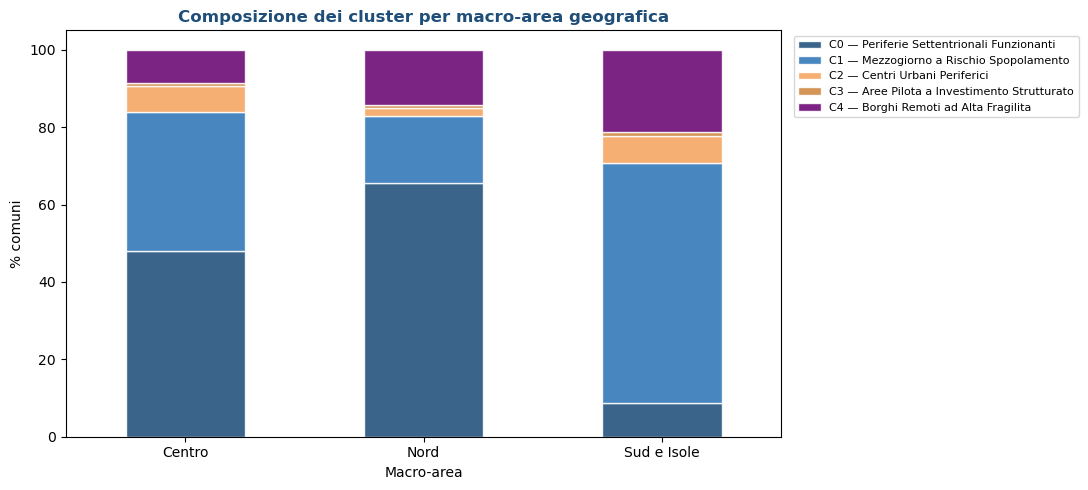

In [12]:
geo = pd.crosstab(
    ai_clean["macro_area"],
    ai_clean["cluster"],
    normalize="index"
) * 100

print("Distribuzione % cluster per macro-area:")
print(geo.round(1))

fig, ax = plt.subplots(figsize=(11, 5))
geo.plot(
    kind="bar", ax=ax, stacked=True,
    color=[PALETTE[i] for i in range(K_OTTIMALE)],
    alpha=0.88, edgecolor="white"
)
ax.set_xlabel("Macro-area", fontsize=10)
ax.set_ylabel("% comuni", fontsize=10)
ax.set_title("Composizione dei cluster per macro-area geografica",
             fontsize=12, fontweight="bold", color=C_DARK)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=10)
ax.legend(
    [f"C{i} — {NOMI_CLUSTER.get(i, str(i))}" for i in range(K_OTTIMALE)],
    fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left"
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "nb07_cluster_per_macroarea.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Esempi di comuni per cluster

Per dare concretezza ai profili statistici
elenchiamo alcuni comuni rappresentativi di ciascun cluster,
scelti come quelli piu vicini al centroide (i piu "tipici").

In [13]:
from sklearn.metrics import pairwise_distances_argmin_min

print("Comuni piu rappresentativi per ciascun cluster:\n")
for c_id in range(K_OTTIMALE):
    mask = ai_clean["cluster"] == c_id
    X_c = X[mask]
    centroid = km_final.cluster_centers_[c_id].reshape(1, -1)
    dists = np.linalg.norm(X_c - centroid, axis=1)
    idx_sorted = np.argsort(dists)[:6]
    comuni_rep = ai_clean[mask].iloc[idx_sorted][["comune","regione","tipo_area",
                                                   "var_pct_18_26","reddito_2022",
                                                   "tempi_percorrenza_min"]]
    print(f"--- C{c_id}: {NOMI_CLUSTER.get(c_id, str(c_id))} (n={mask.sum()}) ---")
    for _, r in comuni_rep.iterrows():
        print(f"  {r['comune']:<28} {r['regione']:<20} "
              f"({r['tipo_area']}) | pop:{r['var_pct_18_26']:+.1f}% "
              f"| redd:€{float(r['reddito_2022']):.0f} "
              f"| dist:{r['tempi_percorrenza_min']:.0f}min")
    print()

Comuni piu rappresentativi per ciascun cluster:

--- C0: Periferie Settentrionali Funzionanti (n=1406) ---
  Bosco Chiesanuova            Veneto               (Intermedio) | pop:-0.1% | redd:€20607 | dist:40min
  San Pancrazio                Trentino-Alto Adige/Südtirol (Intermedio) | pop:-0.3% | redd:€21972 | dist:41min
  Comano Terme                 Trentino-Alto Adige/Südtirol (Intermedio) | pop:-0.1% | redd:€20292 | dist:36min
  San Paolo                    Lombardia            (Intermedio) | pop:-0.8% | redd:€20547 | dist:36min
  Venzone                      Friuli-Venezia Giulia (Intermedio) | pop:-0.3% | redd:€20824 | dist:35min
  Poggio Catino                Lazio                (Intermedio) | pop:+0.9% | redd:€21036 | dist:37min

--- C1: Mezzogiorno a Rischio Spopolamento (n=1365) ---
  Ischia di Castro             Lazio                (Intermedio) | pop:-6.2% | redd:€16355 | dist:40min
  Dragoni                      Campania             (Periferico) | pop:-7.4% | redd:€16789 

## 10. Export per Power BI

Salviamo il dataset arricchito con le colonne `cluster` e `nome_cluster`.
In Power BI potremo aggiungere il cluster come dimensione di filtraggio
e colorare la mappa dei comuni in base al profilo di appartenenza.

In [14]:
export_cols = [
    "codice_comune","comune","regione","macro_area",
    "classe_snai","tipo_area","is_area_interna",
    "tempi_percorrenza_min","pop_2018","pop_2026","var_pct_18_26",
    "reddito_2022","var_reddito_18_22",
    "finanz_totale_1420","ha_finanziamento_1420","gruppo_intervento",
    "programmazione_2127","nome_area_snai",
    "cluster","nome_cluster"
]
export_cols = [c for c in export_cols if c in ai_clean.columns]

ai_clean[export_cols].to_csv(
    PROCESSED_DIR + "clustering_aree_interne.csv", index=False
)
print(f"Salvato: clustering_aree_interne.csv ({len(ai_clean)} righe)")
print()
print("Riepilogo finale cluster:")
summary = ai_clean.groupby(["cluster","nome_cluster"]).agg(
    n_comuni        = ("codice_comune","count"),
    pop_var_med     = ("var_pct_18_26","median"),
    redd_med        = ("reddito_2022","median"),
    dist_med        = ("tempi_percorrenza_min","mean"),
    finanz_med      = ("finanz_totale_1420","mean"),
).reset_index()
print(summary.to_string(index=False))

Salvato: clustering_aree_interne.csv (3549 righe)

Riepilogo finale cluster:
 cluster                           nome_cluster  n_comuni  pop_var_med  redd_med  dist_med   finanz_med
       0   Periferie Settentrionali Funzionanti      1406       -1.030   21216.0 38.584780 6.262610e+04
       1     Mezzogiorno a Rischio Spopolamento      1365       -6.530   15908.0 40.556264 1.187124e+05
       2               Centri Urbani Periferici       172       -1.175   19100.0 37.874419 8.952843e+04
       3 Aree Pilota a Investimento Strutturato        27       -4.980   18018.0 49.570370 5.563564e+06
       4        Borghi Remoti ad Alta Fragilita       579       -5.460   17014.0 70.880311 1.438516e+05


---
## Riepilogo Notebook 07

Il clustering K-Means su 6 variabili socioeconomiche (K=5, scelto per
silhouette score massimo a 0.2146 e maggiore drop di inertia a -14.1%)
ha identificato 5 profili distinti tra le 3.549 Aree Interne italiane:

| Cluster | Nome | N | Caratteristica chiave |
|---------|------|---|----------------------|
| Cluster | Nome | N | Tratto distintivo |
|---------|------|---|-------------------|
| C0 | Periferie Settentrionali Funzionanti | 1.406 | Reddito €21.2K, pop stabile −1%, 73% Nord |
| C1 | Mezzogiorno a Rischio Spopolamento | 1.365 | Reddito €15.9K, −6.5% pop, 66% Sud |
| C2 | Centri Urbani Periferici | 172 | Pop mediana 21.000 ab, distanza solo 38 min |
| C3 | Aree Pilota a Investimento Strutturato | 27 | Finanz. medio €5.5M — 80x la media |
| C4 | Borghi Remoti ad Alta Fragilita | 579 | 71 min dal polo, 56% Ultraperiferici |

Il dato piu sorprendente e il **C3**: su 3.549 Aree Interne analizzate,
solo 27 comuni hanno ricevuto una vera strategia strutturata SNAI.
Meno dell'1% del totale, con finanziamenti 80 volte superiori agli altri.
Questo suggerisce che la SNAI, nel ciclo 14-20, e rimasta un progetto pilota
molto concentrato, non una politica diffusa.

Il **C1** rappresenta la sfida piu urgente sul piano della policy:
1.365 comuni meridionali con i redditi piu bassi e lo spopolamento piu acuto,
che per la grande maggioranza ricevono solo piccoli contributi automatici
anziche una strategia di sviluppo coordinata.